In [199]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neural_net import NeuralNet
import mushrooms as shroom
import graphics
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [200]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X = np.array(X)

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

In [202]:
y = np.astype(y, int)
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [243]:
neural_net = NeuralNet((28**2, 512, 10), learning_rate=0.001, random_state=42)
neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].weights = neural_net.layers[0].initialize("He")
neural_net.layers[-1].activation_method="softmax"
epochs = 20
losses, y_pred = neural_net.train(X_train,
                                  y_train,
                                  epochs,
                                  batch_size = 64,
                                  validate=(X_test, y_test),
                                  binary=True,
                                  lr_scheduling=True)#,
                                  #noise_normaliation=True,
                                  #dropout=True)


EPOCH: 1    LOSS: 0.109943    LOSS CHANGE: 0    TEST ACCURACY: 0.837    TEST ACCURACY CHANGE: 0.837
EPOCH: 2    LOSS: 0.0576983    LOSS CHANGE: -0.05224    TEST ACCURACY: 0.88    TEST ACCURACY CHANGE: 0.0429
EPOCH: 3    LOSS: 0.0485355    LOSS CHANGE: -0.009163    TEST ACCURACY: 0.897    TEST ACCURACY CHANGE: 0.0174
EPOCH: 4    LOSS: 0.0437132    LOSS CHANGE: -0.004822    TEST ACCURACY: 0.905    TEST ACCURACY CHANGE: 0.00836
EPOCH: 5    LOSS: 0.0405873    LOSS CHANGE: -0.003126    TEST ACCURACY: 0.911    TEST ACCURACY CHANGE: 0.00543
EPOCH: 6    LOSS: 0.0382277    LOSS CHANGE: -0.00236    TEST ACCURACY: 0.914    TEST ACCURACY CHANGE: 0.00329
EPOCH: 7    LOSS: 0.036517    LOSS CHANGE: -0.001711    TEST ACCURACY: 0.917    TEST ACCURACY CHANGE: 0.00271
EPOCH: 8    LOSS: 0.0350558    LOSS CHANGE: -0.001461    TEST ACCURACY: 0.921    TEST ACCURACY CHANGE: 0.00436
EPOCH: 9    LOSS: 0.0338701    LOSS CHANGE: -0.001186    TEST ACCURACY: 0.922    TEST ACCURACY CHANGE: 0.00121
EPOCH: 10    LOSS:

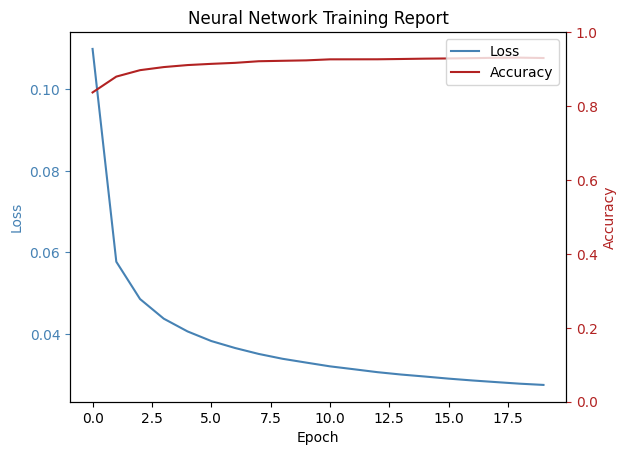

In [244]:
graphics.plot_report(neural_net)

In [245]:
neural_net.export("MNIST_net.csv")

Neural Network exported to MNIST_net.csv


Accuracy: 0.9299285714285714


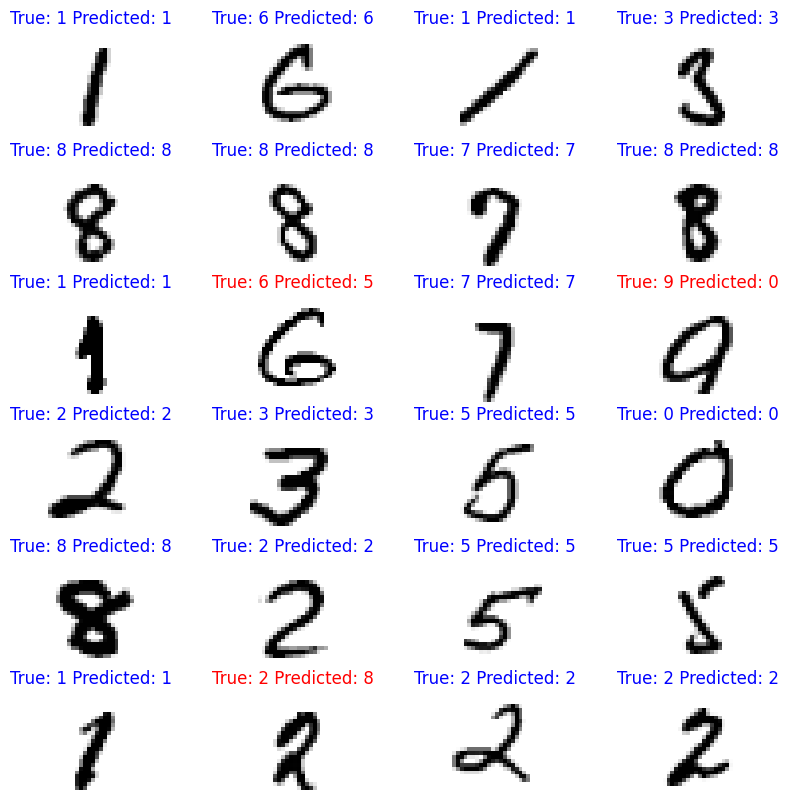

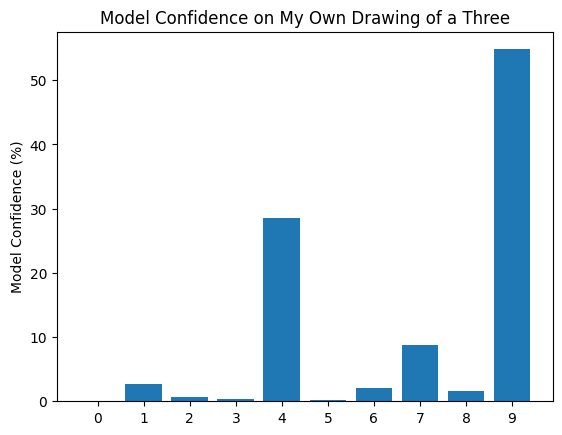

Prediction: [0.00079994 0.02702596 0.00664497 0.00423495 0.28609648 0.00271195
 0.02017007 0.08792255 0.01627326 0.54811986]


In [246]:
from sklearn.metrics import accuracy_score

y_pred = neural_net.predict(X_test)
y_pred_accuracy = np.where(y_pred > 0.5, 1, 0)
print(f"Accuracy: {accuracy_score(y_pred_accuracy, y_test)}")

def display_num(ax, X, i, true, pred):
    X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
    ax.imshow(X_image[i], cmap="gray_r")
    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

rows = 6
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(10, 10))

for i in range(24):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i+300, y_test.argmax(axis=1)[i+300], y_pred.argmax(axis=1)[i+300])
plt.show()
plt.title("Model Confidence on My Own Drawing of a Three")
plt.ylabel("Model Confidence (%)")
plt.bar(np.arange(10), 100*y_pred[11+100].flatten())
plt.xticks(np.arange(10))
plt.show()
print(f"Prediction: {y_pred[11+100]}")

Pred: [[5.06885782e-03 1.81169420e-04 2.88976725e-03 8.95098430e-01
  1.65501369e-06 8.63766517e-02 6.06536129e-03 4.42464907e-06
  4.29633491e-03 1.73474945e-05]]


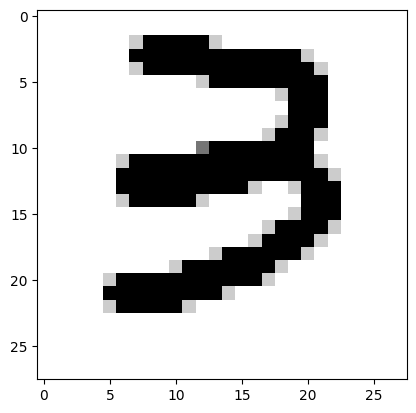

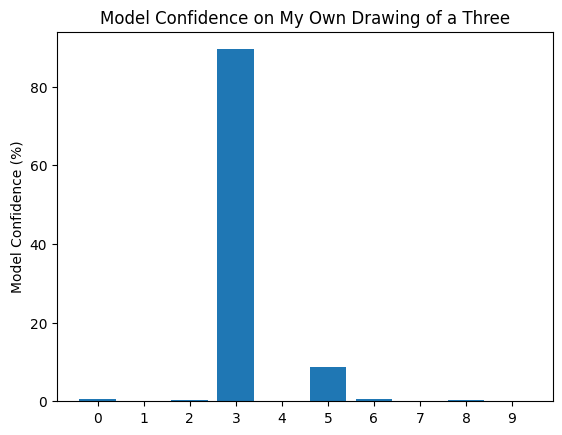

In [247]:
# can it predict my own writing?

my_three = plt.imread('three.png')[:, :28, 0]
X_my = np.array([(1 - my_three).flatten()])
y_pred_my = neural_net.predict(X_my)
print(f"Pred: {y_pred_my}")
plt.imshow(my_three, cmap="gray")
plt.show()
plt.title("Model Confidence on My Own Drawing of a Three")
plt.ylabel("Model Confidence (%)")
plt.bar(np.arange(10), 100*y_pred_my.flatten())
plt.xticks(np.arange(10))
plt.show()